# Lattice class tutorial
------------------------

<!--
[All tutorials](../the_joy_of_AFQMC.ipynb)
-->

In this tutorial, we will learn how to set up a lattice to define a Model Hamiltonian (See __LATTICE_HAMIL_TUTORIAL__ for details on building a Hamiltonian).
The `afqmctools` Python package implements a Lattice class which is responsible for answering geometric questions about a specific lattice such as:

- what are the boundary conditions
- what are the $n^{th}$-nearest neihgbors
- which of those neighbors are "direct" neighbors, and which are image neighbors

and more.
`afqmctools` provides a convenience function, `get_lattice()` to build a Lattice instance given a set of geometric parameters.
In this tutorial, we will explore how the Lattice class works, and the available options for building a Lattice via `get_lattice()`.

## Lattice formalism

We consider lattices with primitive lattice vectors $\vec{a}_1$, and $\vec{a}_2$ (as determined by the lattice "type") which may have a basis, $\{ \delta_p \}$ where $p$ runs over sub-lattice degrees of freedom, and the full cell has dimension $L_1$ x $L_2$.
The positions of lattice sites on sublattice $p$ are given by  
$$
\vec{r}_p = n_1 \vec{a}_1 + n_2 \vec{a}_2  + \vec{\delta}_p
$$,
where $n_1$, and $n_2$ are integers.
Additionally, boundaries are defined normal to the primtive vectors and are labelled acording to the primitive vector which they are normal to.
For example, "boundary 1" is normal to $\vec{a}_1$.
Finally, when bounaries are crossed, a "twist" angle $\vec{\theta} = (\theta_1,\theta_2)$
is used to apply a phase where $\theta_1$/$\theta_2$ is applied when boundary 1 / boundary 2 are crossed, respectively.

<div class="alert alert-block alert-info">
<b>Important:</b>
    Only 2-dimensional lattices are currently implemented / supported.
    Contact the developers if 3-dimensional lattices would be useful to you.
</div>

TODO add a figure illustrating this.

## Summary of get_lattice()

The `get_lattice()` function takes a Python dictionary containging "lattice parameters" as an argument and returns a Lattice instance based on the provided "lattice parameters".

We'll explore the available options individually, but possible lattice parameters are:

- `type` : specifying the lattice type; `square` by default
- `L1` : the lattice dimension along the lattice vector $\vec{a}_1$
- `L2` : the lattice dimenstion along the lattice vector $\vec{a}_2$
- `boundary1` : the boundary *type* of the boundary normal to $\vec{a}_1$ (at $0 * \vec{a}_1$ and $L_1 * \vec{a}_1$ ). Defaults to an open boundary if not specified.
- `boundary2` : the boundary *type* of the boundary normal to $\vec{a}_2$ (at $0 * \vec{a}_2$ and $L_2 * \vec{a}_2$ ). Defaults to an open boundary if not specified.
- `twist` : the twist angle to apply, given as $\vec{\theta} = (\theta_1,\theta_2)$ in units of radians. Defaults to (0.0,0.0)
- `basis` : the set of lattice basis vectors, $\delta_{n}$. Defaults to {(0.0,0.0)}


Below is a minimal example of building a lattice allowing most parameters to take on default values.
We also use `afqmctool`'s `plot_lattice()` function so that we can visualize what we have made.

In [ ]:
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

lattice_params = dict(
    L1 = 4,
    L2 = 4
)

lattice = get_lattice(
    params=lattice_params
)

vis.plot_lattice(lattice)

As we can see, we have constructed a 4x4 squre lattice.
Nearest-neighbors in the direct cell are indicated with a solid black line by default.
The lattice vectors, $\vec{a}_1$ and $\vec{a}_2$,
the lattice coordinate $n_1,n_2$,
and the lattice site index, $i$,
are shown for convenience as well.

### Excercise 1: Play with dimensions

Rerun the cell above with different lattice dimensions.
Try:
- 12 x 4
- 2 x 4
- 4 x 7
- 1 x 10
- anything else you would like to try

## Boundary Conditions

In this section, we will explore the available options for boundary conditions.
To select a boundary type, set `boundary1` and/or `boundary2` in the `lattice_params`
dictionary to a string describing the boundary type.
This is a case insensitive parameter.

As we saw previously, the default boundaries are open.
This can be made explict by setting

```python
lattice_params = dict(
    L1 = 4,
    L2 = 4,
    boundary1= "open",
    boundary2= "open"
)
```

alternatively, periodic boundary conditions (PBC) can be used by setting

```python
lattice_params = dict(
    L1 = 4,
    L2 = 4,
    boundary1= "pbc",
    boundary2= "pbc"
)
```

or mixed boundary conditions can be used by setting, for example,

```python
lattice_params = dict(
    L1 = 4,
    L2 = 4,
    boundary1= "open",
    boundary2= "pbc"
)
```

<div class="alert alert-block alert-warning">
<b>Important:</b>
    When using periodic boundary conditions,
    lattice sites are not allowed to be their own
    image neighbors. So, for example, a 1-dimensional
    lattice can only have PBCs in the "long" direction.
    A ValueError will be raised if any sites are found to be
    image neighbors of themselves.
</div>

### Exercise 2: Play with boundary conditions

Try setting different combintions of boundary conditions
in `lattice_params` in the code block below.
The `plot_lattice()` function will indicate the position of nearest image
neighbors with a black dotted line.

In [ ]:
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

lattice_params = dict(
    L1 = 4,
    L2 = 4,
    boundary1 = "open",
    boundary2 = "pbc",
)

lattice = get_lattice(
    params=lattice_params
)

vis.plot_lattice(lattice)

### Twists

When using periodic boundary conditions (PBCs), a "twist" angle, $\theta = (\theta_1,\theta_2)$ can be set such that, for image neighbors $i,j$,
$$
c^{\dagger}_i c_j = e^{i \theta_1} c^{\dagger}_i c_j
$$
when crossing boundary 1 in the $+\vec{a}_1$ direction
and
$$
c^{\dagger}_i c_j = e^{-i \theta_1} c^{\dagger}_i c_j
$$
when crossing boundary 1 in the $-\vec{a}_1$ direction.
Similar relations apply for boundary 2 and $\theta_2$.
The Lattice class does not directly use the Twist angle, but
stores the relative phase between pairs of lattice site neighbors
if they are set.

All of the following are valid twist inputs:

```pyython
twist = [0.0,0.0]
twist = [3.14,0.0]
twist = [0.0, 0.5]
twist = ["1/2 Pi", "3/2 Pi"]
```

If a twist is provide in `lattice_params`, then
it will be saved as the relative phase between image neighbors
consistent with the boundaries.

For example, in the code block

```python
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

lattice_params = dict(
    L1 = 4,
    L2 = 4,
    boundary1 = "open",
    boundary2 = "pbc",
    twist = ["1/2 Pi", "1/2 Pi"]
)

lattice = get_lattice(
    params=lattice_params
)
```

altough we have provided a twist for both boundary 1 and boundary 2,
only the twist for boundary 2 will be applied since
boundary 1 is not periodic.


## Lattice Types

We provide a few lattice types which can be selected by setting `"type"` to one of `"square"`,
`"triangular"`, `"honeycomb"`, or `"kagome"` in `lattice_params`

Try building a few of these in the code block below.

In [ ]:
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

lattice_params = dict(
    L1 = 4,
    L2 = 4,
    boundary1 = "pbc",
    boundary2 = "pbc",
    type = "honeycomb"
)

lattice = get_lattice(
    params=lattice_params
)

vis.plot_lattice(lattice,title="Honeycomb lattice",show_labels=False)

## Lattice basis

For the `square` lattice type, a lattice basis can be optionally supplied
by setting `basis` in `lattice_params` to a list of vectors which
represent the basis vectors **in spatial coordinates**.
Currently only 2-dimensional lattices are supported, and all basis vectors
must be 2-dimensional.

Note that the honeycomb lattice and the kagame lattice are both special cases
of the triangular lattice with a basis that has been predefined.
If a basis is provided in `lattice_params` for either of these lattices, it will
be ignored.

### Exercise

Play around with setting a basis.

In [ ]:
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

lattice_params = dict(
    L1 = 4,
    L2 = 4,
    boundary1 = "pbc",
    boundary2 = "pbc",
    type = "square",
    basis = [[0.0],[0.5]]
)

lattice = get_lattice(
    params=lattice_params
)

vis.plot_lattice(lattice,title="Square lattice with a basis",show_labels=False)

## Custom lattices

If the lattice that you want is not specifically implemented, you can use the
"custom" lattice.
You will need to specify the lattice vectors, $\vec{a}_1$, and $\vec{a}_2$,
and the lattice basis, $\{ \delta_p \}$.

computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors


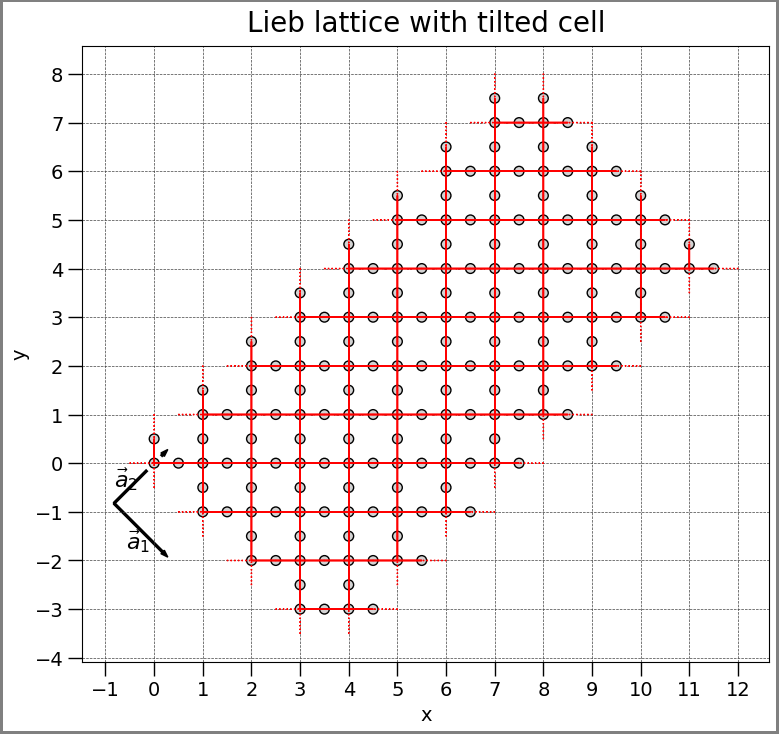

(<Figure size 2400x800 with 1 Axes>,
 <Axes: title={'center': 'Lieb lattice with tilted cell'}, xlabel='x', ylabel='y'>)

In [ ]:
#import numpy as np
#from afqmctools.systems.lattice import get_lattice
#import afqmctools.utils.visualize as vis

basis = [ np.array(delta) for delta in [(0,0),(0.5,0),(0,0.5),(1.0,0),(1.5,0),(1.0,0.5)] ]

lattice_params = dict(
    L1 = 4,
    L2 = 8,
    boundary1 = "pbc",
    boundary2 = "pbc",
    type = "custom",
    basis = basis,
    a1=np.array((1.0,-1.0)),
    a2=np.array((1.0,1.0)),
)

lattice = get_lattice(
    lattice_params
)
vis.plot_lattice(lattice,title="Lieb lattice with tilted cell",show_labels=False)

## Visualizing nth-order neighbors

The `vis.plot_lattice()` function can be used to visualize which pairs of sites
are $n^{th}$-order neighbors.
As you will see in the [Building Lattice Model Hamiltonians Tutorial](../hamiltonian_director/full_v1.ipynb),
$n_{th}$-order neighbor hopping and interactions are available in the lattice model Hamiltonian builder tools.
Visualizing the neighbors can be helpfule or ensuring that the deisred hopping / interactions are being included,
especially when dealing with complicated lattices.

computing and storing 2th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 2th-nearest image neighbors


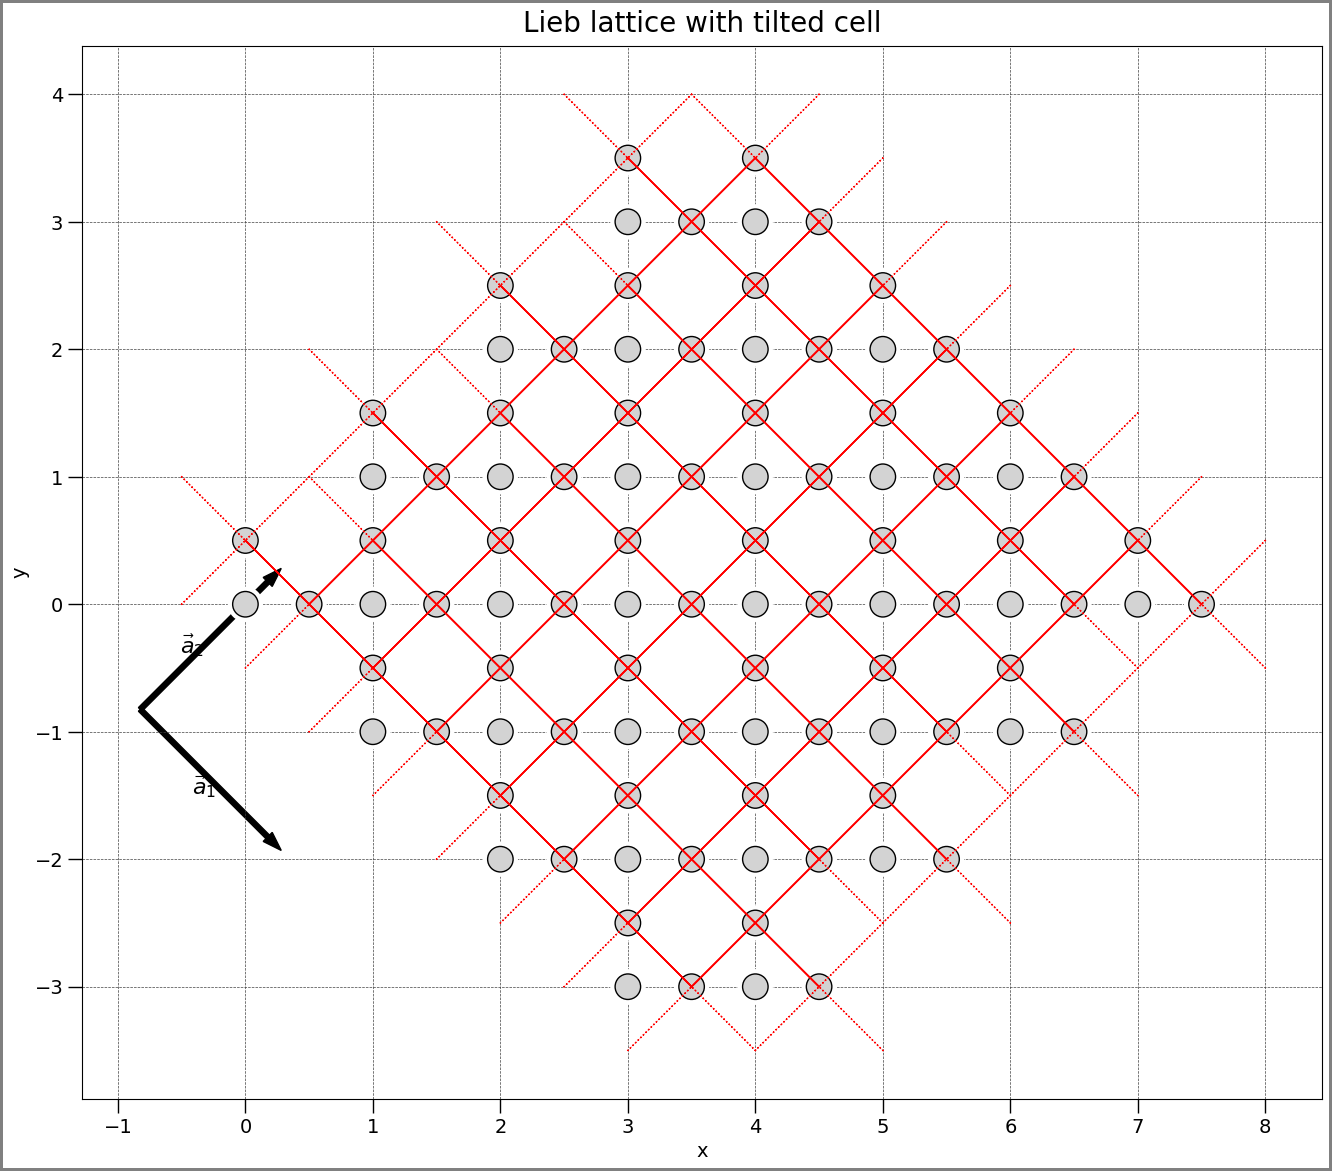

(<Figure size 1600x1600 with 1 Axes>,
 <Axes: title={'center': 'Lieb lattice with tilted cell'}, xlabel='x', ylabel='y'>)

In [ ]:

basis = [ np.array(delta) for delta in [(0,0),(0.5,0),(0,0.5),(1.0,0),(1.5,0),(1.0,0.5)] ]

lattice_params = dict(
    L1 = 4,
    L2 = 4,
    boundary1 = "pbc",
    boundary2 = "pbc",
    type = "custom",
    basis = basis,
    a1=np.array((1.0,-1.0)),
    a2=np.array((1.0,1.0)),
)

lattice = get_lattice(
    lattice_params
)
vis.plot_lattice(
    lattice,
    title="Lieb lattice with tilted cell",
    show_labels=False,
    nth_neighbor=2
)

# Archive of Possible Examples

## a water molecule:

TODO: write an intro. The goal here is to shift everyone's brains to thinking
about mapping atoms in a solid onto a lattice model without the complication of multiple sites.


In [ ]:
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

lattice_params = dict(
    L1 = 1,
    L2 = 1,
    type = 'square',
    basis = [[0.,0.],[-0.5,-0.5],[0.5,-0.5]]
)

lattice = get_lattice(
    params=lattice_params
)

vis.plot_lattice(lattice,title="Water Molecule",show_labels=False)

## Lieb Lattice

The Cuprates are a class of high-temperature superconductors which consiste of 2-dimensional layers of CuO$_2$ and other materials.
The Cu and O atoms are arranged in the Leib lattice as shown below.


In [ ]:
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

lattice_params = dict(
    L1 = 4,
    L2 = 4,
    type = 'square',
    basis = [[0.,0.],[0.5,0.0],[0.0,0.5]]
)

lattice = get_lattice(
    params=lattice_params
)

vis.plot_lattice(lattice,title="Lieb Lattice",show_labels=False)

## Kagome Lattice


In [ ]:
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

lattice_params = dict(
    L1 = 4,
    L2 = 4,
    boundary1 = "pbc",
    boundary2 = "pbc",
    type = 'kagome'
)

lattice = get_lattice(
    params=lattice_params
)

vis.plot_lattice(lattice,title="Kagome Lattice",show_labels=False)

In [ ]:
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

lattice_params = dict(
    L1 = 4,
    L2 = 4,
    boundary1 = "pbc",
    boundary2 = "pbc",
    type = 'triangular'
)

lattice = get_lattice(
    params=lattice_params
)

vis.plot_lattice(lattice,title="Triangular Lattice",show_labels=False)

In [ ]:
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

lattice_params = dict(
    L1 = 4,
    L2 = 4,
    boundary1 = "pbc",
    boundary2 = "pbc",
    type = 'honeycomb'
)

lattice = get_lattice(
    params=lattice_params
)

vis.plot_lattice(lattice,title="Honeycomb Lattice",show_labels=False)

In [ ]:
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

lattice_params = dict(
    L1 = 8,
    L2 = 8,
    boundary1 = "pbc",
    boundary2 = "pbc",
    type = 'square'
)

lattice = get_lattice(
    params=lattice_params
)

vis.plot_lattice(lattice,title="Square Lattice",show_labels=False)